# 04. MGE & AMR Gene Colocalization

Analyses mobile genetic elements (MGEs) and their association with AMR genes in 22 *Aeromonas* strains.

**Analysis sections:**
1. MGE distribution overview — IS families and types across 22 strains
2. IS element burden per strain
3. MGE presence heatmap — strain × IS family
4. **Case study 1:** *A. caviae* SU4 — Tn521 + Class I integron + AMR gene cluster
5. **Case study 2:** *A. rivipollensis* A539 — IncQ plasmid + qnrS2
6. **Extended:** AMR gene co-resistance network — which AMR genes co-occur?

**Key finding from Lee et al. (2023):**  
> *"Co-localization of Tn521 + IntI1 + sul1 + aadA1 implies co-selection of mercury and antibiotic resistance"*

**Reference:** Lee et al. (2023), *Frontiers in Microbiology*, 14:1175304

In [1]:
# ── dependencies ──────────────────────────────────────────────
# pip install pandas numpy seaborn matplotlib plotly

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
import plotly.graph_objects as go
import re
from pathlib import Path

PROC = Path('../data/processed')
RAW  = Path('../data/raw')
print('Libraries loaded OK')

Libraries loaded OK


---
## 1. Load & prepare MGE data

In [3]:
# ── load S4 ───────────────────────────────────────────────────
strain_id_row = pd.read_excel(RAW / 'Table_4.XLSX', sheet_name='Table_S4',
                              header=None, skiprows=3, nrows=1)
strain_ids = [str(s).strip() for s in strain_id_row.iloc[0, 3:].tolist()]

s4 = pd.read_excel(RAW / 'Table_4.XLSX', sheet_name='Table_S4', header=4)
s4.columns = ['IS_family', 'subgroup', 'MGE_type'] + list(s4.columns[3:])
cols = list(s4.columns); cols[3:] = strain_ids; s4.columns = cols
s4['IS_family'] = s4['IS_family'].ffill()
s4['subgroup']  = s4['subgroup'].ffill()
s4 = s4.dropna(subset=['MGE_type'])
s4 = s4[~s4['MGE_type'].isin(['StrainID', 'Type of MGE'])].reset_index(drop=True)

# ── parse cells: IS name + copy number ───────────────────────
def parse_mge(val):
    if pd.isna(val) or str(val).strip() in ['', 'nan']:
        return 0, 0, ''
    val = str(val).strip()
    m = re.search(r'\((\d+)\)', val)
    copy_n = int(m.group(1)) if m else 1
    name   = re.sub(r'\s*\(\d+\)', '', val).strip()
    return 1, copy_n, name

# build binary, copy_number, name matrices
binary_data, copy_data, name_data = {}, {}, {}
for sid in strain_ids:
    present, copies, names = zip(*s4[sid].apply(parse_mge))
    binary_data[sid] = list(present)
    copy_data[sid]   = list(copies)
    name_data[sid]   = list(names)

s4_binary = s4[['IS_family', 'subgroup', 'MGE_type']].copy()
s4_copies = s4[['IS_family', 'subgroup', 'MGE_type']].copy()
for sid in strain_ids:
    s4_binary[sid] = binary_data[sid]
    s4_copies[sid] = copy_data[sid]

# separate by MGE type
is_only = s4_binary[s4_binary['MGE_type'].isin(['IS', 'IS5'])]
tn_only = s4_binary[s4_binary['MGE_type'].str.contains('transposon', case=False, na=False)]
mite    = s4_binary[s4_binary['MGE_type'].str.contains('MITE', case=False, na=False)]

# species map
species_map = {
    'SU4':'A. caviae', 'A533':'A. dhakensis', 'A536':'A. dhakensis',
    'A537':'A. hydrophila', 'A539':'A. rivipollensis', 'SU3':'A. rivipollensis',
    'SU9':'A. rivipollensis', 'SU15':'A. rivipollensis', 'SC42':'A. rivipollensis',
    'OY1':'A. rivipollensis', 'OY52':'A. media', 'SU6':'A. bestiarum',
    'SL22':'A. bestiarum', 'SU58-3':'A. bestiarum', 'LP308':'A. piscicola',
    'SU2':'A. salmonicida', 'SL19':'A. salmonicida', 'SL21':'A. salmonicida',
    'SC45':'A. salmonicida', 'OY56':'A. salmonicida', 'OY59':'A. salmonicida',
    'LP441':'A. salmonicida'
}
species_palette = {
    'A. salmonicida':'#E07B54', 'A. piscicola':'#5B8DB8',
    'A. bestiarum':'#6BAF92',  'A. media':'#9B7BB8',
    'A. rivipollensis':'#D4A843', 'A. caviae':'#C4706A',
    'A. hydrophila':'#7BA87B',  'A. dhakensis':'#8AA6C4',
}

print(f'S4 shape: {s4.shape}')
print(f'IS elements: {len(is_only)} | Transposons: {len(tn_only)} | MITEs: {len(mite)}')
print(f'Strains: {strain_ids}')

S4 shape: (52, 25)
IS elements: 40 | Transposons: 9 | MITEs: 3
Strains: ['SU4', 'A533', 'A536', 'A537', 'A539', 'SU3', 'SU9', 'SU15', 'SC42', 'OY1', 'OY52', 'SU6', 'SL22', 'SU58-3', 'LP308', 'SU2', 'SL19', 'SL21', 'SC45', 'OY56', 'OY59', 'LP441']


---
## 2. IS element burden per strain

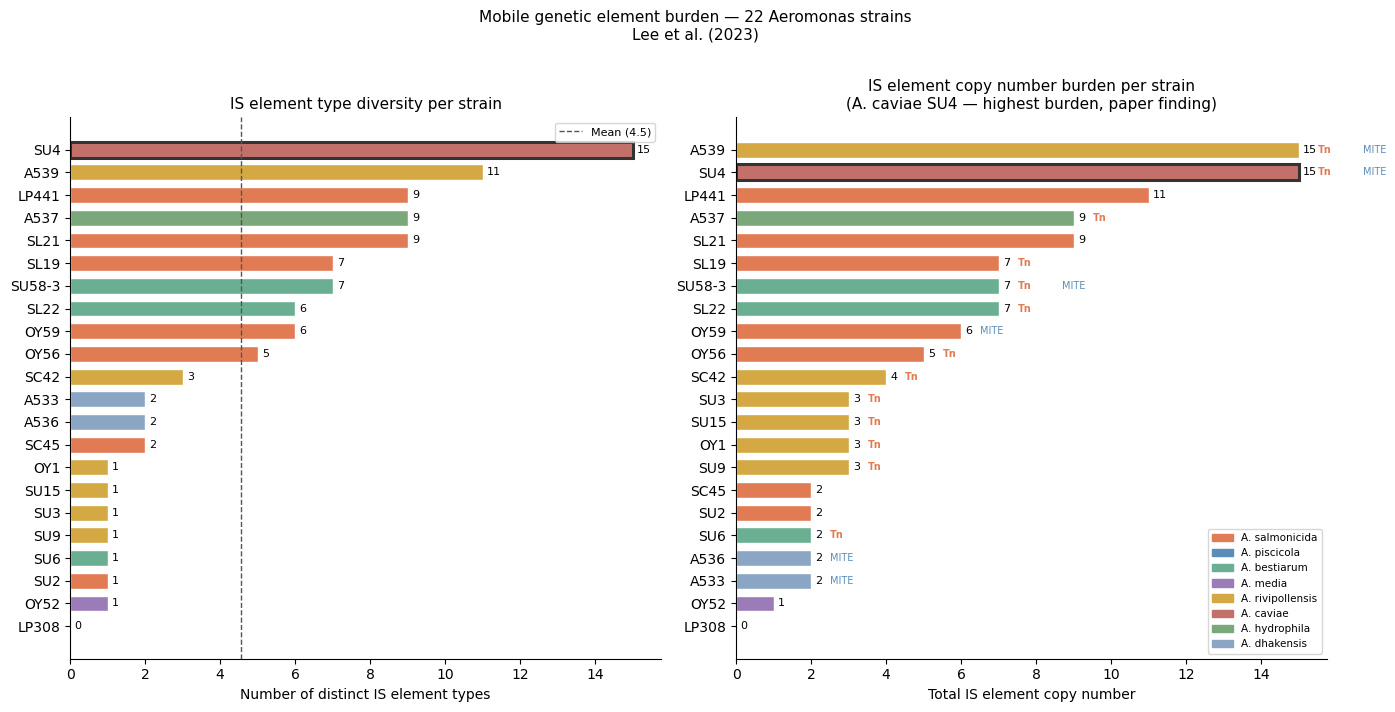

Saved: fig_mge_burden.png


In [4]:
# ── total IS count per strain ────────────────────────────────
is_count = is_only[strain_ids].sum().rename('is_count')
is_copies_total = s4_copies[
    s4_copies['MGE_type'].isin(['IS', 'IS5'])
][strain_ids].sum().rename('is_copies')

burden_df = pd.DataFrame({
    'strain'   : strain_ids,
    'species'  : [species_map.get(s, 'Unknown') for s in strain_ids],
    'is_types' : is_count.values,
    'is_copies': is_copies_total.values,
    'has_Tn'   : (tn_only[strain_ids].sum() > 0).astype(int).values,
    'has_MITE' : (mite[strain_ids].sum() > 0).astype(int).values,
})

# sort by is_copies ascending so highest (SU4) is at top of barh
burden_df = burden_df.sort_values('is_copies', ascending=True)

# ── plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
colors = [species_palette.get(sp, '#CCCCCC') for sp in burden_df['species']]

# left: IS type diversity — sort by is_types ascending (same strain order as right)
burden_left = burden_df.sort_values('is_types', ascending=True)
colors_left = [species_palette.get(sp, '#CCCCCC') for sp in burden_left['species']]
bars_l = axes[0].barh(burden_left['strain'], burden_left['is_types'],
                      color=colors_left, edgecolor='white', height=0.7)
axes[0].bar_label(bars_l, padding=3, fontsize=8)
# highlight SU4
for bar, strain in zip(axes[0].patches, burden_left['strain']):
    if strain == 'SU4':
        bar.set_edgecolor('#333333')
        bar.set_linewidth(2.2)
axes[0].set_xlabel('Number of distinct IS element types', fontsize=10)
axes[0].set_title('IS element type diversity per strain', fontsize=11)
axes[0].axvline(burden_df['is_types'].mean(), color='#555', linestyle='--',
                linewidth=1, label=f'Mean ({burden_df["is_types"].mean():.1f})')
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

# right: IS copy number — sort by is_copies ascending (SU4 at top)
bars_r = axes[1].barh(burden_df['strain'], burden_df['is_copies'],
                      color=colors, edgecolor='white', height=0.7)
axes[1].bar_label(bars_r, padding=3, fontsize=8)
# highlight SU4
for bar, strain in zip(axes[1].patches, burden_df['strain']):
    if strain == 'SU4':
        bar.set_edgecolor('#333333')
        bar.set_linewidth(2.2)
axes[1].set_xlabel('Total IS element copy number', fontsize=10)
axes[1].set_title(
    'IS element copy number burden per strain\n'
    '(A. caviae SU4 — highest burden, paper finding)',
    fontsize=11
)
for i_bar, (_, row) in enumerate(burden_df.iterrows()):
    offset = row['is_copies'] + 0.5
    if row['has_Tn']:
        axes[1].text(offset, i_bar, 'Tn', va='center',
                     fontsize=7, color='#E07B54', fontweight='bold')
        offset += 1.2
    if row['has_MITE']:
        axes[1].text(offset, i_bar, 'MITE', va='center',
                     fontsize=7, color='#5B8DB8')
sp_handles = [mpatches.Patch(color=c, label=s)
              for s, c in species_palette.items()
              if s in burden_df['species'].values]
axes[1].legend(handles=sp_handles, fontsize=7.5, loc='lower right')
sns.despine(ax=axes[1])

plt.suptitle('Mobile genetic element burden — 22 Aeromonas strains\n'
             'Lee et al. (2023)', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(PROC / 'fig_mge_burden.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_mge_burden.png')


---
## 3. MGE presence heatmap — strain × IS family

C:\Users\SAMSUNG\AppData\Local\Temp\ipykernel_19600\1445414833.py:92: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  abs_patch  = mpatches.Patch(color='#F0F4F8', edgecolor='#CCCCCC', label='Absent')


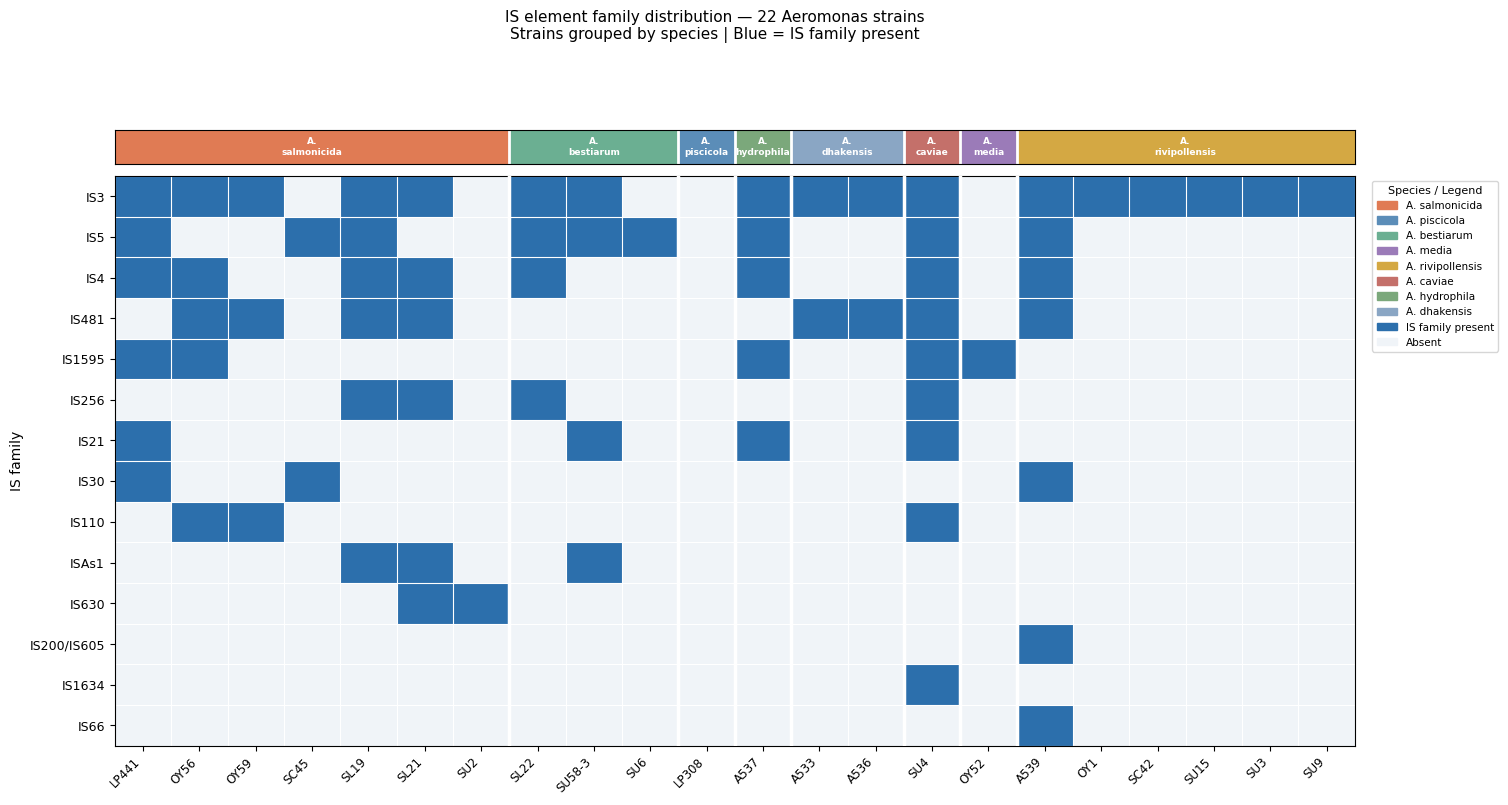

Saved: fig_is_family_heatmap.png


In [5]:
# ── IS family × strain heatmap ───────────────────────────────
family_matrix = (
    is_only.groupby('IS_family')[strain_ids]
    .max()
)
species_order_list = ['A. salmonicida','A. bestiarum','A. piscicola',
                      'A. hydrophila','A. dhakensis','A. caviae',
                      'A. media','A. rivipollensis']
strain_order = sorted(
    strain_ids,
    key=lambda s: (
        species_order_list.index(species_map.get(s,'z'))
        if species_map.get(s,'z') in species_order_list else 99, s
    )
)
family_matrix = family_matrix[strain_order]
fam_total = family_matrix.sum(axis=1).sort_values(ascending=False)
family_matrix = family_matrix.loc[fam_total.index]

n_strains = len(strain_order)
n_fams    = len(family_matrix)

# ── figure layout: extra row on top for species color bar ─────
fig = plt.figure(figsize=(16, 8))
gs  = plt.GridSpec(2, 1, height_ratios=[0.06, 1], hspace=0.04)
ax_top  = fig.add_subplot(gs[0])   # species color bar
ax_main = fig.add_subplot(gs[1])   # heatmap

z = family_matrix.values.astype(float)

# ── main heatmap ──────────────────────────────────────────────
ax_main.imshow(z, aspect='auto', cmap=plt.matplotlib.colors.ListedColormap(
    ['#F0F4F8', '#2C6FAC']), vmin=0, vmax=1, interpolation='nearest'
)

# grid lines
ax_main.set_xticks(np.arange(-0.5, n_strains, 1), minor=True)
ax_main.set_yticks(np.arange(-0.5, n_fams, 1), minor=True)
ax_main.grid(which='minor', color='white', linewidth=0.8)
ax_main.tick_params(which='minor', size=0)

# species group dividers — white vertical lines
prev_sp = None
for j, sid in enumerate(strain_order):
    sp = species_map.get(sid, '')
    if sp != prev_sp and j > 0:
        ax_main.axvline(j - 0.5, color='white', linewidth=2.5, zorder=5)
    prev_sp = sp

# axis labels
ax_main.set_xticks(range(n_strains))
ax_main.set_xticklabels(strain_order, rotation=45, ha='right', fontsize=8.5)
ax_main.set_yticks(range(n_fams))
ax_main.set_yticklabels(family_matrix.index, fontsize=9)
ax_main.set_ylabel('IS family', fontsize=10)

# ── top: species color bar ────────────────────────────────────
sp_colors_arr = [
    species_palette.get(species_map.get(s, ''), '#DDDDDD')
    for s in strain_order
]
sp_rgba = np.array([[plt.matplotlib.colors.to_rgba(c)] for c in sp_colors_arr])
ax_top.imshow(sp_rgba.transpose(1, 0, 2), aspect='auto', interpolation='nearest')
ax_top.set_xticks([])
ax_top.set_yticks([])

# species labels in color bar
prev_sp = None
sp_start = 0
for j, sid in enumerate(strain_order):
    sp = species_map.get(sid, '')
    if sp != prev_sp:
        if prev_sp:
            mid = (sp_start + j - 1) / 2
            ax_top.text(mid, 0, prev_sp.replace('A. ', 'A.\n'),
                        ha='center', va='center', fontsize=6.5,
                        color='white', fontweight='bold')
            ax_top.axvline(j - 0.5, color='white', linewidth=2)
        sp_start = j
        prev_sp = sp
# last group
mid = (sp_start + n_strains - 1) / 2
ax_top.text(mid, 0, prev_sp.replace('A. ', 'A.\n'),
            ha='center', va='center', fontsize=6.5,
            color='white', fontweight='bold')

# ── legend ────────────────────────────────────────────────────
sp_handles = [mpatches.Patch(color=c, label=s)
              for s, c in species_palette.items()
              if s in [species_map.get(sid) for sid in strain_order]]
pres_patch = mpatches.Patch(color='#2C6FAC', label='IS family present')
abs_patch  = mpatches.Patch(color='#F0F4F8', edgecolor='#CCCCCC', label='Absent')
ax_main.legend(
    handles=sp_handles + [pres_patch, abs_patch],
    title='Species / Legend',
    bbox_to_anchor=(1.01, 1), loc='upper left',
    fontsize=7.5, title_fontsize=8
)

# ── title — placed above the color bar ────────────────────────
fig.suptitle(
    'IS element family distribution — 22 Aeromonas strains\n'
    'Strains grouped by species | Blue = IS family present',
    fontsize=11, y=1.03
)

plt.savefig(PROC / 'fig_is_family_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_is_family_heatmap.png')


---
## 4. Case study 1 — *A. caviae* SU4: Tn521 + Class I integron

The paper's key finding for SU4: co-localization of a **Tn521 transposon** (mercury resistance operon)  
with a **Class I integron (IntI1)** carrying **sul1** and **aadA1**, and efflux pump **qacEΔ1** and **tet(E)**.  
This implies **co-selection** — mercury contamination may maintain antibiotic resistance.

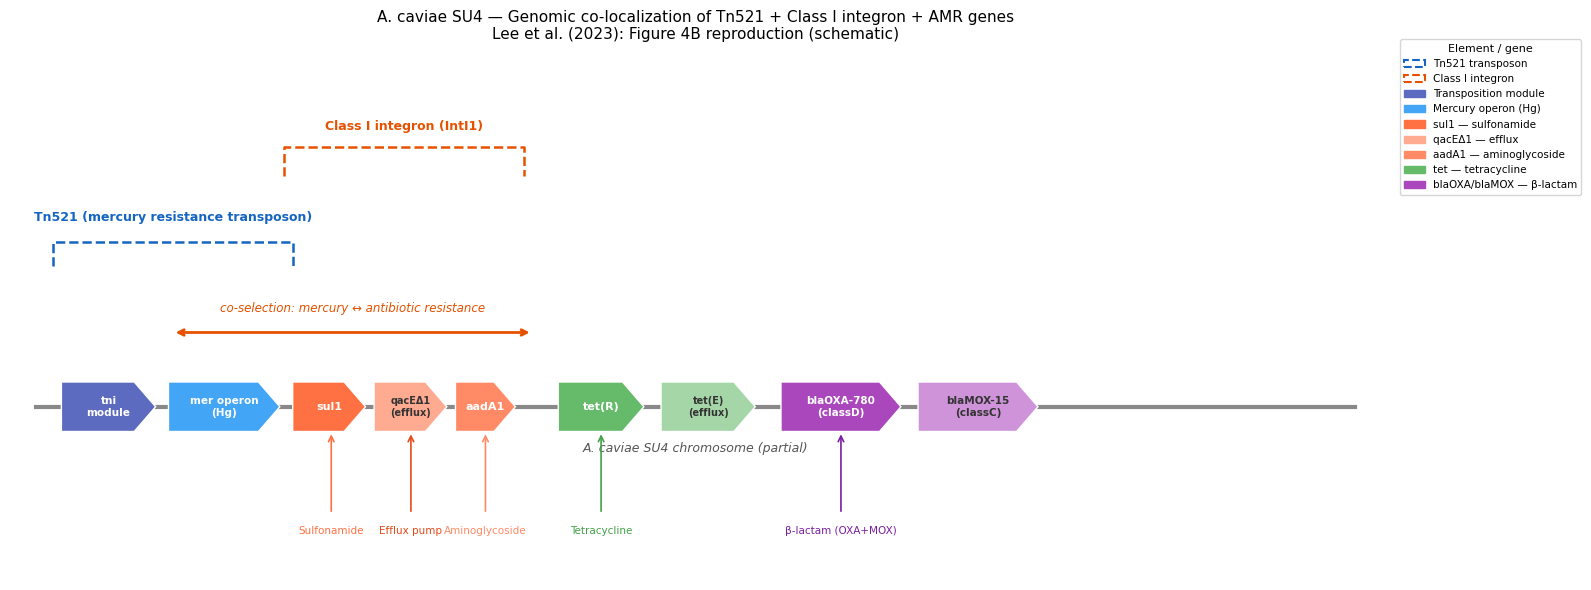

Saved: fig_case_SU4.png


In [6]:
# ── SU4 genomic element diagram ──────────────────────────────
# Gene order (paper Figure 4B): tni | mer operon | sul1 | qacEΔ1 | aadA1
# Tn521 and IntI1 blocks separated to avoid overlap

fig, ax = plt.subplots(figsize=(16, 6))
ax.set_xlim(0, 16)
ax.set_ylim(-1.8, 4.5)
ax.axis('off')
ax.set_title(
    'A. caviae SU4 — Genomic co-localization of Tn521 + Class I integron + AMR genes\n'
    'Lee et al. (2023): Figure 4B reproduction (schematic)',
    fontsize=11, pad=15
)

def draw_arrow(ax, x, y, width, label, color, text_color='white', fontsize=9):
    h, tip = 0.6, 0.25
    xs = [x, x+width-tip, x+width, x+width-tip, x]
    ys = [y, y, y+h/2, y+h, y+h]
    ax.fill(xs, ys, color=color, edgecolor='white', linewidth=1, zorder=3)
    ax.text(x+width/2, y+h/2, label, ha='center', va='center',
            fontsize=fontsize, color=text_color, fontweight='bold', zorder=4)

# chromosome backbone
ax.plot([0.3, 15.7], [0.3, 0.3], color='#888', linewidth=3, zorder=1)
ax.text(8, -0.25, 'A. caviae SU4 chromosome (partial)',
        ha='center', fontsize=9, color='#555', style='italic')

# ── Tn521: x=0.5–3.3, y bracket at y=2.2 ─────────────────────
tn_x1, tn_x2 = 0.5, 3.3
# bracket
ax.plot([tn_x1, tn_x1, tn_x2, tn_x2], [2.0, 2.3, 2.3, 2.0],
        color='#1565C0', linewidth=1.8, linestyle='--')
ax.text((tn_x1+tn_x2)/2, 2.55,
        'Tn521 (mercury resistance transposon)',
        ha='center', fontsize=9, color='#1565C0', fontweight='bold')

# Tn521 genes
draw_arrow(ax, 0.6,  0.0, 1.1, 'tni\nmodule',      '#5C6BC0', fontsize=7.5)
draw_arrow(ax, 1.85, 0.0, 1.3, 'mer operon\n(Hg)', '#42A5F5', fontsize=7.5)

# ── Class I integron: x=3.2–6.0, y bracket at y=3.4 ──────────
int_x1, int_x2 = 3.2, 6.0
ax.plot([int_x1, int_x1, int_x2, int_x2], [3.1, 3.45, 3.45, 3.1],
        color='#E65100', linewidth=1.8, linestyle='--')
ax.text((int_x1+int_x2)/2, 3.65,
        'Class I integron (IntI1)',
        ha='center', fontsize=9, color='#E65100', fontweight='bold')

# Integron genes — CORRECT ORDER: sul1 → qacEΔ1 → aadA1
draw_arrow(ax, 3.3,  0.0, 0.85, 'sul1',          '#FF7043', fontsize=8)
draw_arrow(ax, 4.25, 0.0, 0.85, 'qacEΔ1\n(efflux)', '#FFAB91', '#333', fontsize=7)
draw_arrow(ax, 5.2,  0.0, 0.7,  'aadA1',         '#FF8A65', fontsize=8)

# ── flanking AMR genes ────────────────────────────────────────
draw_arrow(ax, 6.4,  0.0, 1.0, 'tet(R)',          '#66BB6A', fontsize=8)
draw_arrow(ax, 7.6,  0.0, 1.1, 'tet(E)\n(efflux)', '#A5D6A7', '#333', fontsize=7)
draw_arrow(ax, 9.0,  0.0, 1.4, 'blaOXA-780\n(classD)', '#AB47BC', fontsize=7.5)
draw_arrow(ax, 10.6, 0.0, 1.4, 'blaMOX-15\n(classC)', '#CE93D8', '#333', fontsize=7.5)

# ── resistance class annotations (below) ─────────────────────
annots = [
    (3.75,  'Sulfonamide', '#FF7043'),
    (4.68,  'Efflux pump', '#E64A19'),
    (5.55,  'Aminoglycoside', '#FF8A65'),
    (6.9,   'Tetracycline', '#43A047'),
    (9.7,   'β-lactam (OXA+MOX)', '#7B1FA2'),
]
for tx, label, color in annots:
    ax.annotate('', xy=(tx, 0), xytext=(tx, -1.0),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    ax.text(tx, -1.15, label, ha='center', fontsize=7.5,
            color=color, va='top')

# ── co-selection arrow ────────────────────────────────────────
ax.annotate('',
    xy=(6.1, 1.2), xytext=(1.9, 1.2),
    arrowprops=dict(arrowstyle='<->', color='#E65100', lw=2)
)
ax.text(4.0, 1.45,
        'co-selection: mercury ↔ antibiotic resistance',
        ha='center', fontsize=8.5, color='#E65100', style='italic')

# legend
leg_items = [
    mpatches.Patch(facecolor='white', edgecolor='#1565C0', linestyle='--',
                   linewidth=1.5, label='Tn521 transposon'),
    mpatches.Patch(facecolor='white', edgecolor='#E65100', linestyle='--',
                   linewidth=1.5, label='Class I integron'),
    mpatches.Patch(color='#5C6BC0', label='Transposition module'),
    mpatches.Patch(color='#42A5F5', label='Mercury operon (Hg)'),
    mpatches.Patch(color='#FF7043', label='sul1 — sulfonamide'),
    mpatches.Patch(color='#FFAB91', label='qacEΔ1 — efflux'),
    mpatches.Patch(color='#FF8A65', label='aadA1 — aminoglycoside'),
    mpatches.Patch(color='#66BB6A', label='tet — tetracycline'),
    mpatches.Patch(color='#AB47BC', label='blaOXA/blaMOX — β-lactam'),
]
ax.legend(handles=leg_items, bbox_to_anchor=(1.01, 1.05),
          loc='upper left', fontsize=7.5,
          title='Element / gene', title_fontsize=8)

plt.tight_layout()
plt.savefig(PROC / 'fig_case_SU4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_case_SU4.png')


---
## 5. Case study 2 — *A. rivipollensis* A539: IncQ plasmid + qnrS2

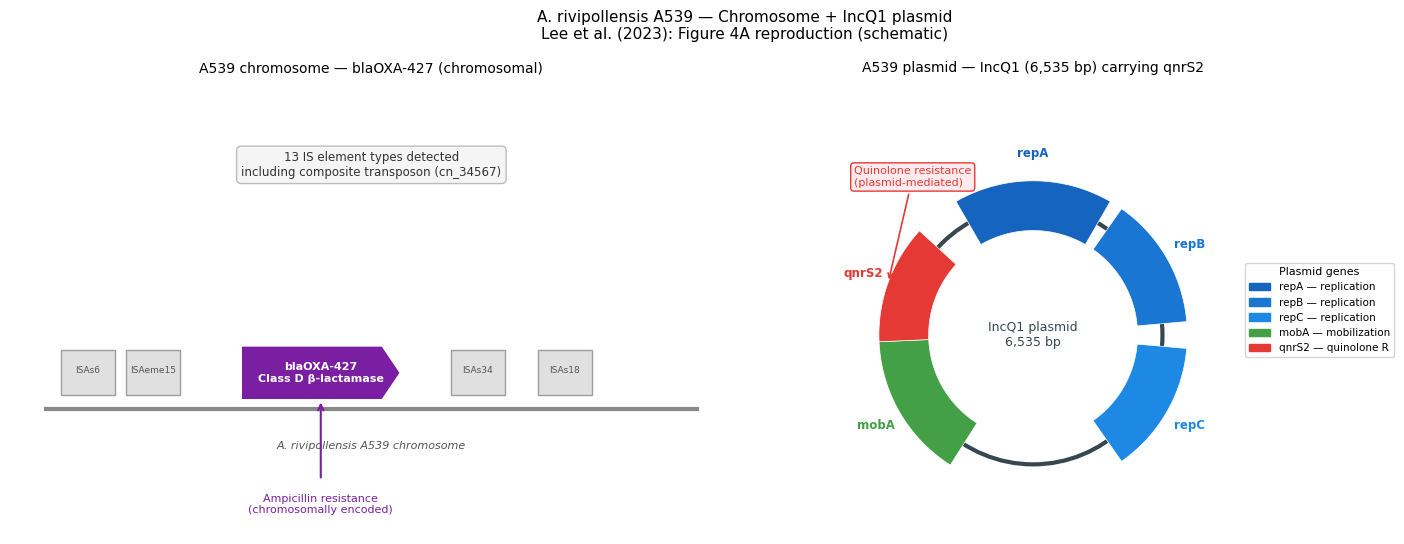

Saved: fig_case_A539.png


In [7]:
# ── A539 diagram — redesigned for consistency with SU4 style ─
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

def draw_arrow(ax, x, y, width, label, color, text_color='white', fontsize=9):
    h, tip = 0.6, 0.25
    xs = [x, x+width-tip, x+width, x+width-tip, x]
    ys = [y, y, y+h/2, y+h, y+h]
    ax.fill(xs, ys, color=color, edgecolor='white', linewidth=1, zorder=3)
    ax.text(x+width/2, y+h/2, label, ha='center', va='center',
            fontsize=fontsize, color=text_color, fontweight='bold', zorder=4)

# ── left: chromosome context ──────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 3.5)
ax.axis('off')
ax.set_title('A539 chromosome — blaOXA-427 (chromosomal)',
             fontsize=10, pad=10)

# backbone BELOW gene arrows (y=-0.1, genes at y=0.0)
ax.plot([0.5, 9.5], [-0.1, -0.1], color='#888', linewidth=3, zorder=1)
ax.text(5, -0.55, 'A. rivipollensis A539 chromosome',
        ha='center', fontsize=8, color='#555', style='italic')

# blaOXA-427 gene arrow (y=0.0, sits above backbone)
draw_arrow(ax, 3.2, 0.0, 2.2,
           'blaOXA-427\nClass D β-lactamase', '#7B1FA2', fontsize=8)

# annotation below
ax.annotate('', xy=(4.3, 0), xytext=(4.3, -0.9),
            arrowprops=dict(arrowstyle='->', color='#7B1FA2', lw=1.5))
ax.text(4.3, -1.05,
        'Ampicillin resistance\n(chromosomally encoded)',
        ha='center', fontsize=8, color='#7B1FA2', va='top')

# IS elements as small grey boxes flanking the gene
for x_pos, name in [(0.7,'ISAs6'), (1.6,'ISAeme15'),
                    (6.1,'ISAs34'), (7.3,'ISAs18')]:
    ax.add_patch(plt.Rectangle(
        (x_pos, 0.05), 0.75, 0.5,
        facecolor='#E0E0E0', edgecolor='#9E9E9E', linewidth=1, zorder=3
    ))
    ax.text(x_pos+0.375, 0.3, name,
            ha='center', fontsize=6.5, color='#555', zorder=4)

# info box
ax.text(5, 2.5,
    '13 IS element types detected\n'
    'including composite transposon (cn_34567)',
    ha='center', fontsize=8.5, color='#333',
    bbox=dict(boxstyle='round,pad=0.4',
              facecolor='#F5F5F5', edgecolor='#BDBDBD')
)

# ── right: plasmid circular diagram ──────────────────────────
ax2 = axes[1]
ax2.set_xlim(-2, 2)
ax2.set_ylim(-2, 2.5)
ax2.set_aspect('equal')
ax2.axis('off')
ax2.set_title('A539 plasmid — IncQ1 (6,535 bp) carrying qnrS2',
              fontsize=10, pad=10)

circle = plt.Circle((0, 0), 1.3, fill=False,
                     color='#37474F', linewidth=3)
ax2.add_patch(circle)
ax2.text(0, 0, 'IncQ1 plasmid\n6,535 bp',
         ha='center', va='center', fontsize=9, color='#37474F')

plasmid_genes = [
    (90,  60,  'repA',  '#1565C0'),
    (30,  50,  'repB',  '#1976D2'),
    (330, 50,  'repC',  '#1E88E5'),
    (210, 55,  'mobA',  '#43A047'),
    (160, 45,  'qnrS2', '#E53935'),
]
for angle_center, arc_span, label, color in plasmid_genes:
    theta1 = np.radians(angle_center - arc_span/2)
    theta2 = np.radians(angle_center + arc_span/2)
    thetas = np.linspace(theta1, theta2, 50)
    r_inner, r_outer = 1.05, 1.55
    xs = np.concatenate([
        r_inner * np.cos(thetas),
        r_outer * np.cos(thetas[::-1])
    ])
    ys = np.concatenate([
        r_inner * np.sin(thetas),
        r_outer * np.sin(thetas[::-1])
    ])
    ax2.fill(xs, ys, color=color, edgecolor='white', linewidth=0.5, zorder=3)
    mid_theta = np.radians(angle_center)
    lx = 1.82 * np.cos(mid_theta)
    ly = 1.82 * np.sin(mid_theta)
    ax2.text(lx, ly, label, ha='center', va='center',
             fontsize=8.5, color=color, fontweight='bold')

ax2.annotate(
    'Quinolone resistance\n(plasmid-mediated)',
    xy=(1.55*np.cos(np.radians(160)), 1.55*np.sin(np.radians(160))),
    xytext=(-1.8, 1.5), fontsize=8, color='#E53935',
    arrowprops=dict(arrowstyle='->', color='#E53935', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.3',
              facecolor='#FFEBEE', edgecolor='#E53935')
)

leg2 = [
    mpatches.Patch(color='#1565C0', label='repA — replication'),
    mpatches.Patch(color='#1976D2', label='repB — replication'),
    mpatches.Patch(color='#1E88E5', label='repC — replication'),
    mpatches.Patch(color='#43A047', label='mobA — mobilization'),
    mpatches.Patch(color='#E53935', label='qnrS2 — quinolone R'),
]
axes[1].legend(handles=leg2, bbox_to_anchor=(1.02, 0.5), loc='center left',
               fontsize=7.5, title='Plasmid genes', title_fontsize=8)

plt.suptitle(
    'A. rivipollensis A539 — Chromosome + IncQ1 plasmid\n'
    'Lee et al. (2023): Figure 4A reproduction (schematic)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(PROC / 'fig_case_A539.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_case_A539.png')


---
## 6. Extended: AMR gene co-occurrence across 19 WGS strains

In [8]:
# ── AMR gene binary matrix (Table 1 data) ────────────────────
amr_genes = [
    'cphA1','cphA2','cphA5','cphA1/cphA3',
    'blaMOX-9','blaMOX-15','blaAQU','cepS',
    'blaOXA-12','blaOXA-427','blaOXA-780','blaOXA-956',
    'tet(E)','qacEΔ1','sul1','aadA1','qnrS2'
]
table1_raw = [
    ['SU4-2', 'A. caviae',        '',            'blaMOX-15', 'blaOXA-780',  'tet(E)','qacEΔ1','sul1','aadA1'],
    ['A533',  'A. dhakensis',     'cphA2',       'blaAQU',    'blaOXA-12',   '','','',''],
    ['A537',  'A. hydrophila',    'cphA2',       'cepS',      'blaOXA-12',   'tet(E)','','',''],
    ['A539',  'A. rivipollensis', '',            '',          'blaOXA-427',  '','','','qnrS2'],
    ['SU3',   'A. rivipollensis', '',            '',          'blaOXA-427',  '','','',''],
    ['SC42',  'A. rivipollensis', '',            '',          'blaOXA-427',  '','','',''],
    ['OY1',   'A. rivipollensis', '',            '',          'blaOXA-427',  '','','',''],
    ['OY52',  'A. media',         '',            'blaMOX-9',  'blaOXA-427',  '','','',''],
    ['SU6-2', 'A. bestiarum',     'cphA1',       '',          'blaOXA-956',  '','','',''],
    ['SL22',  'A. bestiarum',     'cphA1',       '',          'blaOXA-956',  '','','',''],
    ['SU58-3','A. bestiarum',     'cphA1',       '',          'blaOXA-956',  '','','',''],
    ['LJP308','A. piscicola',     'cphA1',       '',          'blaOXA-956',  '','','',''],
    ['SU2',   'A. salmonicida',   'cphA1',       '',          'blaOXA-956',  '','','',''],
    ['SL19',  'A. salmonicida',   'cphA1/cphA3', '',          'blaOXA-956',  '','','',''],
    ['SL21',  'A. salmonicida',   'cphA5',       '',          'blaOXA-956',  '','','',''],
    ['SC45',  'A. salmonicida',   'cphA5',       '',          'blaOXA-956',  '','','',''],
    ['OY56',  'A. salmonicida',   'cphA1',       '',          'blaOXA-956',  '','','',''],
    ['OY59',  'A. salmonicida',   'cphA5',       '',          'blaOXA-956',  '','','',''],
    ['LJP441','A. salmonicida',   'cphA1',       '',          'blaOXA-956',  '','','',''],
]

rows = []
for entry in table1_raw:
    strain, species = entry[0], entry[1]
    all_genes = ' '.join(entry[2:])
    row = {'strain': strain, 'species': species}
    for gene in amr_genes:
        row[gene] = 1 if gene in all_genes else 0
    rows.append(row)

amr_matrix = pd.DataFrame(rows).set_index('strain')
amr_binary  = amr_matrix.drop(columns=['species'])

# genes present in ≥2 strains
gene_freq   = amr_binary.sum()
genes_common = gene_freq[gene_freq >= 2].index.tolist()
amr_common  = amr_binary[genes_common]

# Jaccard similarity matrix
cooccur = amr_common.T.dot(amr_common).astype(float)
jaccard = pd.DataFrame(index=genes_common, columns=genes_common, dtype=float)
for g1 in genes_common:
    for g2 in genes_common:
        intersection = cooccur.loc[g1, g2]
        union = (amr_common[g1] | amr_common[g2]).sum()
        jaccard.loc[g1, g2] = intersection / union if union > 0 else 0
np.fill_diagonal(jaccard.values, 1.0)

# gene class map
gene_class = {
    'cphA1':'Class B', 'cphA2':'Class B', 'cphA5':'Class B',
    'cphA1/cphA3':'Class B',
    'blaMOX-9':'Class C', 'blaMOX-15':'Class C',
    'blaAQU':'Class C', 'cepS':'Class C',
    'blaOXA-12':'Class D', 'blaOXA-427':'Class D',
    'blaOXA-780':'Class D', 'blaOXA-956':'Class D',
    'tet(E)':'Efflux', 'qacEΔ1':'Efflux',
    'sul1':'Other', 'aadA1':'Other', 'qnrS2':'Other'
}
class_palette_amr = {
    'Class B':'#1565C0', 'Class C':'#2E7D32',
    'Class D':'#6A1B9A', 'Efflux':'#E65100', 'Other':'#37474F'
}

print(f'AMR binary matrix: {amr_binary.shape}')
print(f'Genes in ≥2 strains: {genes_common}')
print('Jaccard matrix computed ✓')


AMR binary matrix: (19, 17)
Genes in ≥2 strains: ['cphA1', 'cphA2', 'cphA5', 'blaOXA-12', 'blaOXA-427', 'blaOXA-956', 'tet(E)']
Jaccard matrix computed ✓


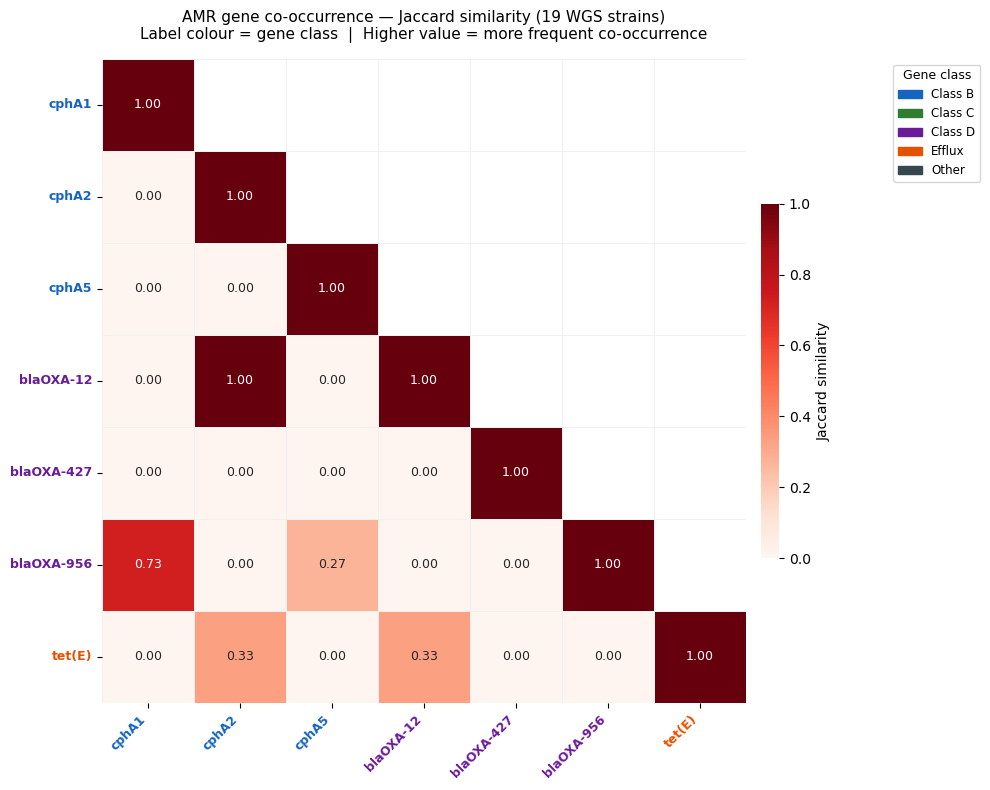

Saved: fig_amr_cooccurrence.png


In [9]:
# ── AMR co-occurrence heatmap — redesigned ───────────────────
fig, ax = plt.subplots(figsize=(10, 8))

mask = np.triu(np.ones_like(jaccard.astype(float), dtype=bool), k=1)
jac_vals = jaccard.astype(float).copy()
jac_vals[mask] = np.nan

sns.heatmap(
    jac_vals,
    ax=ax,
    cmap='Reds',
    vmin=0, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 9},
    linewidths=0.6,
    linecolor='#F0F0F0',
    cbar_kws={'label': 'Jaccard similarity', 'shrink': 0.55, 'pad': 0.02},
    mask=mask
)

# colour tick labels by gene class — no overlapping bars
for tick in ax.get_xticklabels():
    cls = gene_class.get(tick.get_text(), 'Other')
    tick.set_color(class_palette_amr.get(cls, '#333'))
    tick.set_fontweight('bold')
for tick in ax.get_yticklabels():
    cls = gene_class.get(tick.get_text(), 'Other')
    tick.set_color(class_palette_amr.get(cls, '#333'))
    tick.set_fontweight('bold')

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

class_handles = [
    mpatches.Patch(color=c, label=cls)
    for cls, c in class_palette_amr.items()
]
ax.legend(
    handles=class_handles, title='Gene class',
    bbox_to_anchor=(1.22, 1), loc='upper left',
    fontsize=8.5, title_fontsize=9, frameon=True
)
ax.set_title(
    'AMR gene co-occurrence — Jaccard similarity (19 WGS strains)\n'
    'Label colour = gene class  |  Higher value = more frequent co-occurrence',
    fontsize=11, pad=14
)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig(PROC / 'fig_amr_cooccurrence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_amr_cooccurrence.png')


In [10]:
# ── save outputs and summary ──────────────────────────────────
burden_df.to_csv(PROC / 'mge_burden_summary.csv', index=False)
jaccard.to_csv(PROC / 'amr_cooccurrence_jaccard.csv')

print('=== Files saved this notebook ===')
outputs = [
    'fig_mge_burden.png',
    'fig_is_family_heatmap.png',
    'fig_case_SU4.png',
    'fig_case_A539.png',
    'fig_amr_cooccurrence.png',
    'mge_burden_summary.csv',
    'amr_cooccurrence_jaccard.csv',
]
for f in outputs:
    path = PROC / f
    status = '✓' if path.exists() else '✗'
    print(f'  {status} {f}')

=== Files saved this notebook ===
  ✓ fig_mge_burden.png
  ✓ fig_is_family_heatmap.png
  ✓ fig_case_SU4.png
  ✓ fig_case_A539.png
  ✓ fig_amr_cooccurrence.png
  ✓ mge_burden_summary.csv
  ✓ amr_cooccurrence_jaccard.csv
